In [45]:
import yfinance as yf
import plotly.graph_objects as go
from utils.trade import Trade

In [46]:
symbol = "EURUSD=X"
df = yf.download(symbol, period="max", interval="1h")

fast_ma = 21
slow_ma = 50

SLOW_MA = f"Slow_MA_({slow_ma})"
FAST_MA = f"Fast_MA_({fast_ma})"
ATR = f"{7} ATR"

df[SLOW_MA] = df["Close"].rolling(slow_ma).mean()
df[FAST_MA] = df["Close"].rolling(fast_ma).mean()

df[ATR] = (df['High'] - df['Low']).rolling(7).mean()
df["PnL"] = 0

df.drop(columns=["Volume"], inplace=True)
df.columns = df.columns.droplevel("Ticker")
df.dropna(inplace=True)

df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Slow_MA_(50),Fast_MA_(21),7 ATR,PnL
Datetime,,,,,,,,
2026-04-29 12:00:00+00:00,1.170275,1.171097,1.169864,1.170549,1.171497,1.171163,0.000900,0
2026-04-29 13:00:00+00:00,1.169180,1.170549,1.168770,1.170275,1.171392,1.171059,0.001057,0
2026-04-29 14:00:00+00:00,1.170549,1.170549,1.168770,1.169317,1.171307,1.171006,0.001193,0
2026-04-29 15:00:00+00:00,1.169864,1.170823,1.169317,1.170412,1.171222,1.170928,0.001271,0
2026-04-29 16:00:00+00:00,1.170001,1.170001,1.169864,1.169864,1.171142,1.170869,0.001193,0


In [47]:
rr = 2

equity_curve = []
positions: list[Trade] = []
PnL_curve = []

for i in range(1, len(df)):
    candel = df.iloc[i]
    prev_candel = df.iloc[i - 1]

    price = candel["Close"]
    atr = candel[ATR]

    if len(positions) == 0:
        if prev_candel[FAST_MA] < prev_candel[SLOW_MA] and candel[FAST_MA] > candel[SLOW_MA]:
            positions.append(Trade(
                entry=price,
                sl=price - atr,
                tp=price + atr * rr,
            ).activate())
    else:
        _trade = positions[-1]
        _exit_price = _trade.sl

        # if sl of last trade is hit
        # elif tp is hit → cascade
        # else keep position
        if candel["Low"] <= _exit_price:
            pnl = sum((_exit_price - p.entry)/(p.entry - p.sl) for p in positions)
            df.loc[i, "PnL"] = pnl
            PnL_curve.append(pnl)
            positions.clear()
        elif candel["High"] > _trade.tp:
            _new_trade = Trade(
                entry=_trade.tp,
                sl=_trade.tp - atr,
                tp=_trade.tp + atr * rr,
            ).activate()
            for p in positions:
                p.sl = _new_trade.sl
            positions.append(_new_trade)
        else:
            continue

df['Balance'] = df['PnL'].cumsum()

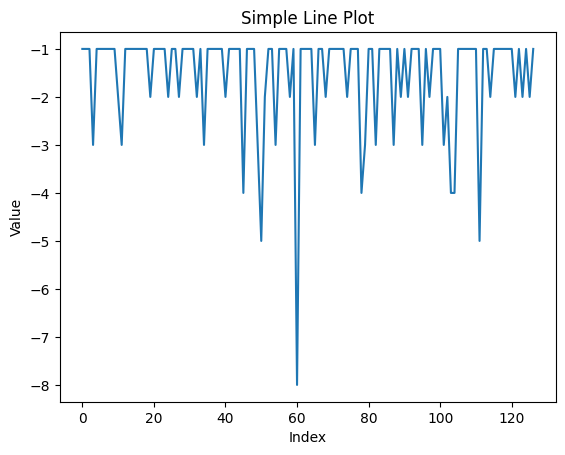

In [ ]:
import matplotlib.pyplot as plt

plt.plot(PnL_curve)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Simple Line Plot")

plt.show()

In [ ]:
import pandas as pd

fig = go.Figure()

df.index = pd.to_datetime(df.index, utc=True)

fig.add_trace(go.Scatter(
    x=df.index,
    y=df['Balance'],
    mode='lines',
    name='Equity Curve'
))

fig.update_layout(
    title=f"Cascading Strategy Backtest ({symbol})",
    xaxis_title="Date",
    yaxis_title="Equity",
    template="plotly_dark",
    height=800,
    width=1000
)

fig.show()